# Cifar-100 Classification with CNNs
This can be found at Google Colab at https://bit.ly/3Oj1YeG  

In [ ]:
#!pip install tensorflow

In [1]:
import tensorflow as tf
from keras.datasets import cifar100
from keras.layers import Dense, Flatten, Conv2D,  BatchNormalization, MaxPooling2D, Activation, InputLayer, Dropout
from keras.losses import categorical_crossentropy
from keras.utils import to_categorical
from keras.callbacks import Callback, EarlyStopping
from keras.optimizers import Adam
from keras.models import Sequential
from keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
print("Tesorflow version:", tf.__version__)

Tesorflow version: 2.21.0


C:\ProgramData\miniforge3\envs\DL\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data (50000, 32, 32, 3)
Training label (50000, 1)
Max number of training label 99


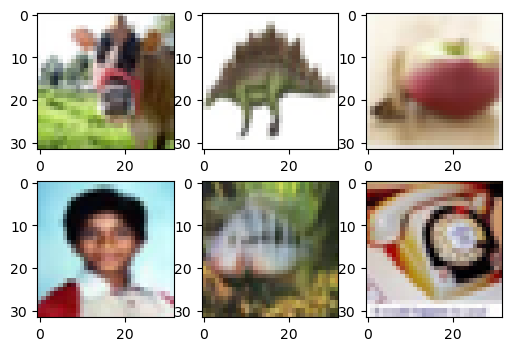

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()
print(f"Training data {X_train.shape}")
print(f"Training label {y_train.shape}")
print(f"Max number of training label {np.max(y_train)}")

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 3, figsize=(6, 4)) # create subplots 2 rows 3 columnns

for index, img in enumerate(X_train[0:6]):
    panel = axs[int(index/3),index%3]   # find the panel by  2dimensional indexing
    panel.imshow(img, cmap="gray_r")    # plot the picture in the panel




## Network without Convolutions

This was a model we previously tested


In [3]:
model = Sequential([
      InputLayer((32,32,3)),
      Flatten(), # 32x32x3 -> 3084
      BatchNormalization(),
      Dense(512, activation='sigmoid', kernel_regularizer=l2(0.01)),
      Dropout(0.2),
      BatchNormalization(),
      Dense(512, activation='sigmoid', kernel_regularizer=l2(0.01)),
      Dropout(0.2),
      Dense(100, activation="softmax", kernel_regularizer=l2(0.01))
      ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 3072)                │          12,288 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,901,668 (7.25 MB)

 Trainable params: 1,894,500 (7.23 MB)

 Non-trainable params: 7,168 (28.00 KB)

Original Results were:

...
Epoch 30/30
167/167 --- 10s 36ms/step - accuracy: 0.1091 - loss: 4.2159 - val_accuracy: 0.1083 - val_loss: 4.2153
...
It had ~2 Million parameter


In [4]:
# And here a solution with convolutions:
model = Sequential()
model.add(InputLayer((32,32,3)))
model.add(Dropout(0.2))
model.add(Conv2D(100,kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D())
model.add(Conv2D(200,kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(100, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(100, activation="softmax", kernel_regularizer=l2(0.01)))
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)                  │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 30, 30, 100)         │           2,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 100)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 200)         │         180,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 200)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 7200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7200)                │          28,800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │         720,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          10,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 942,000 (3.59 MB)

 Trainable params: 927,600 (3.54 MB)

 Non-trainable params: 14,400 (56.25 KB)

In [ ]:
opt=Adam(
    learning_rate=0.0001,
    beta_1=0.8,
    beta_2=0.999)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=100
)

Epoch 1/30
166/500 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.0368 - loss: 7.5206

In [6]:
prediction = tf.argmax(model.predict(X_test),axis=1)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(prediction, y_test.reshape(-1))
display(cm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


array([[77, 12,  8, ...,  0,  4,  3],
       [ 0, 41,  0, ...,  0,  0,  0],
       [ 0,  0,  7, ...,  0,  3,  0],
       ...,
       [ 0,  0,  1, ..., 27,  1,  0],
       [ 3,  0,  5, ...,  1, 14,  0],
       [ 0,  1,  3, ...,  2,  4, 43]])

In [7]:
classes = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy',
           'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
           'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest',
           'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
           'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
           'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum',
           'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper',
           'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
           'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',
           'wolf', 'woman', 'worm']

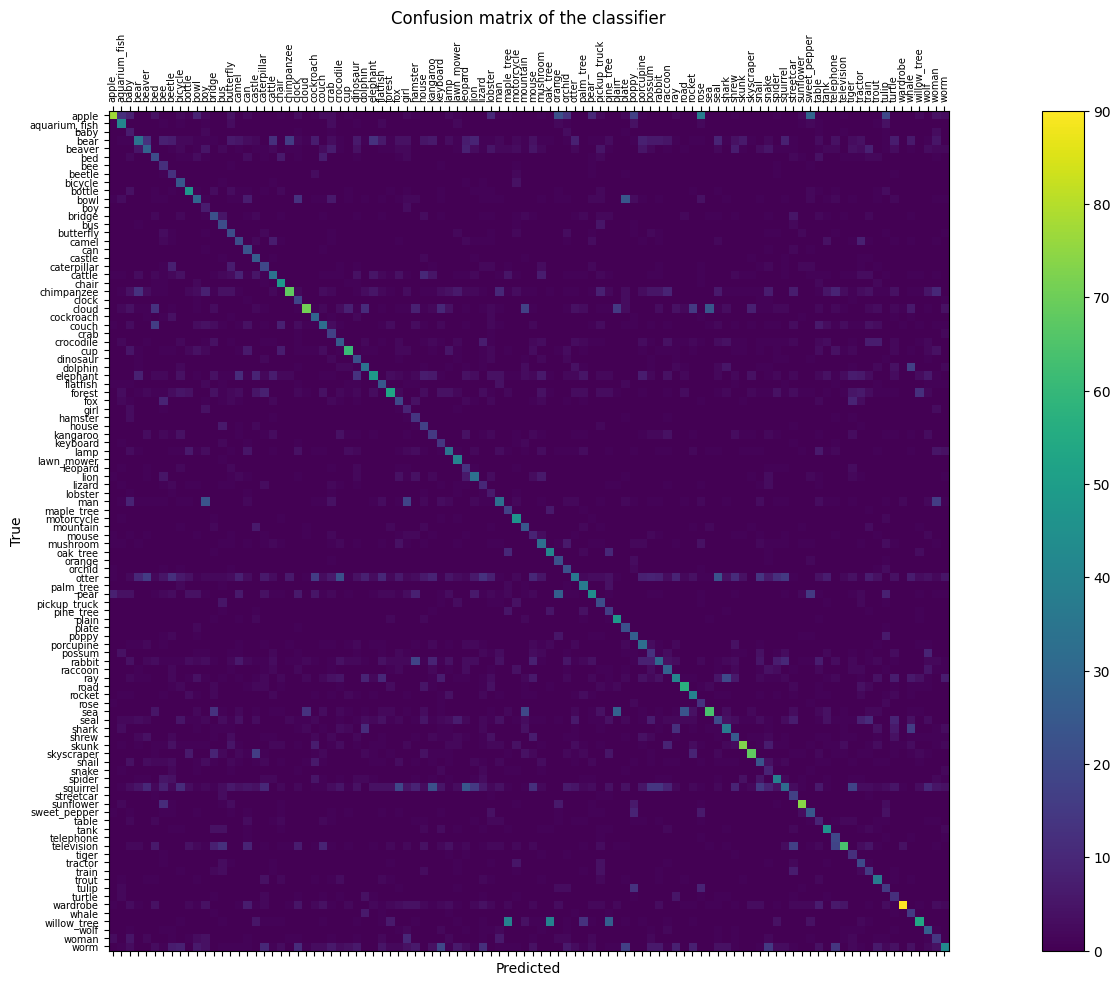

In [8]:
# Plot the confusion matrix
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(24,24))
ax = fig.add_subplot(211)
cax = ax.matshow(cm)
plt.title('Confusion matrix of the classifier')
fig.colorbar(cax)
# Set ticks positions
ax.set_xticks(range(100))
ax.set_yticks(range(100))
ax.set_xticklabels(classes, rotation='vertical', fontsize=7)
ax.set_yticklabels(classes, fontsize=7)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()